### =============================================================================
### A Network-Sensitive Framework for Assessing the Feasibility of Distributed
### VQAs in Multi-QPU Architectures
### Script: Drawing dimensions from benchmark circuits
### Author: Waldemir Cambiucci
### Date: March 16, 2026
####
### Description:
### This script parses structured benchmark output files for QAOA and VQE
### circuits, extracts circuit-level structural attributes, computes derived
### metrics, and generates analytical visualizations to support feasibility
### assessment in distributed multi-QPU environments.
###
### Main tasks:
### - Parse benchmark output blocks from text files
### - Extract structural circuit attributes and gate counts
### - Identify algorithm, platform, representation, and toolchain metadata
### - Compute derived metrics such as two-qubit gate density and normalized
###   structural ratios
### - Organize benchmark instances into analysis groups
### - Generate summary plots for comparative evaluation across benchmark groups
### Inputs:
### - Structured benchmark output text file
### - Circuit analysis records derived from QAOA and VQE benchmark instances
### Outputs:
### - Pandas DataFrame with extracted and derived circuit metrics
### - PNG figures for exploratory and comparative structural analysis
### Scope:
### This script supports the structural characterization stage of the distributed
### VQA feasibility workflow under network-sensitive multi-QPU assumptions.
###
### Project:
### Distributed VQA feasibility analysis under network-sensitive conditions
### =============================================================================

In [38]:
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


INPUT_FILE = "output_20260317_004103.txt"
OUTPUT_DIR = "plots"

In [39]:
def parse_output_file(filename: str) -> pd.DataFrame:
    text = Path(filename).read_text(encoding="utf-8")
    blocks = re.split(r"\n-+\n", text)

    records = []

    for block in blocks:
        if "FILE:" not in block:
            continue

        def extract(pattern, default=None, cast=None):
            m = re.search(pattern, block, re.MULTILINE)
            if not m:
                return default
            value = m.group(1).strip()
            if cast:
                try:
                    return cast(value)
                except Exception:
                    return default
            return value

        file_path = extract(r"FILE:\s*(.+)")
        status = extract(r"STATUS:\s*(.+)")
        depth = extract(r"DEPTH:\s*(\d+)", cast=int)
        size = extract(r"SIZE:\s*(\d+)", cast=int)
        width = extract(r"WIDTH:\s*(\d+)", cast=int)
        num_qubits = extract(r"NUMBER OF QUBITS:\s*(\d+)", cast=int)
        num_clbits = extract(r"NUMBER OF CLASSICAL BITS:\s*(\d+)", cast=int)
        num_cx = extract(r"NUMBER OF CX / CNOT GATES:\s*(\d+)", cast=int)
        num_cz = extract(r"NUMBER OF CZ GATES:\s*(\d+)", default=0, cast=int)
        num_rxx = extract(r"NUMBER OF RXX GATES:\s*(\d+)", default=0, cast=int)
        num_rzz = extract(r"NUMBER OF RZZ GATES:\s*(\d+)", default=0, cast=int)
        total_ops = extract(r"TOTAL OPERATIONS:\s*(\d+)", cast=int)
        ops_breakdown = extract(r"OPERATIONS BREAKDOWN:\s*(.+)", default="")

        lower_path = file_path.lower()

        algorithm = "qaoa" if "\\qaoa " in lower_path else "vqe" if "\\vqe " in lower_path else "unknown"
        representation = "native" if "native" in lower_path else "indep" if "indep" in lower_path else "unknown"

        platform = "unknown"
        for p in ["ibm", "ionq", "quantinuum", "rigetti"]:
            if p in lower_path:
                platform = p
                break

        toolchain = "qiskit" if "qiskit" in lower_path else "tket" if "tket" in lower_path else "unknown"

        group = f"{algorithm} | {representation} | {platform}"

        records.append({
            "file": file_path,
            "status": status,
            "depth": depth,
            "size": size,
            "width": width,
            "num_qubits": num_qubits,
            "num_clbits": num_clbits,
            "num_cx": num_cx,
            "num_cz": num_cz,
            "num_rxx": num_rxx,
            "num_rzz": num_rzz,
            "total_ops": total_ops,
            "ops_breakdown": ops_breakdown,
            "algorithm": algorithm,
            "representation": representation,
            "platform": platform,
            "toolchain": toolchain,
            "group": group,
        })

    df = pd.DataFrame(records)
    df = df[df["status"] == "OK"].copy()
    return df


def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["num_two_qubit_gates"] = (
        df["num_cx"].fillna(0)
        + df["num_cz"].fillna(0)
        + df["num_rxx"].fillna(0)
        + df["num_rzz"].fillna(0)
    )

    df["two_qubit_density"] = np.where(
        df["total_ops"] > 0,
        df["num_two_qubit_gates"] / df["total_ops"],
        0.0
    )

    df["depth_per_qubit"] = np.where(
        df["num_qubits"] > 0,
        df["depth"] / df["num_qubits"],
        0.0
    )

    df["size_per_qubit"] = np.where(
        df["num_qubits"] > 0,
        df["size"] / df["num_qubits"],
        0.0
    )

    df["depth_size_ratio"] = np.where(
        df["size"] > 0,
        df["depth"] / df["size"],
        0.0
    )

    return df


def make_output_dir():
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


def get_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def save_plot(fig, name: str, timestamp: str):
    filepath = Path(OUTPUT_DIR) / f"{name}_{timestamp}.png"
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")


def plot_scatter_depth_vs_qubits(df: pd.DataFrame, timestamp: str):
    fig, ax = plt.subplots(figsize=(13, 8))

    groups = sorted(df["group"].unique())

    for group in groups:
        subset = df[df["group"] == group]
        bubble_size = subset["size"].astype(float) * 2.0

        ax.scatter(
            subset["num_qubits"],
            subset["depth"],
            s=bubble_size,
            alpha=0.65,
            label=group
        )

    ax.set_title("Circuit Structure: Depth vs Number of Qubits")
    ax.set_xlabel("Number of Qubits")
    ax.set_ylabel("Depth")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    fig.tight_layout()
    save_plot(fig, "scatter_depth_vs_qubits", timestamp)
    plt.show()


def plot_stacked_binary_gates_by_group(df: pd.DataFrame, timestamp: str):
    summary = (
        df.groupby("group", as_index=False)[["num_cx", "num_cz", "num_rxx", "num_rzz"]]
        .mean()
        .sort_values(["num_cx", "num_cz", "num_rxx", "num_rzz"], ascending=False)
    )

    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(summary))
    cx = summary["num_cx"].values
    cz = summary["num_cz"].values
    rxx = summary["num_rxx"].values
    rzz = summary["num_rzz"].values

    ax.bar(x, cx, label="CX")
    ax.bar(x, cz, bottom=cx, label="CZ")
    ax.bar(x, rxx, bottom=cx + cz, label="RXX")
    ax.bar(x, rzz, bottom=cx + cz + rxx, label="RZZ")

    ax.set_title("Average Two-Qubit Gate Composition by Group")
    ax.set_xlabel("Group")
    ax.set_ylabel("Average Gate Count")
    ax.set_xticks(x)
    ax.set_xticklabels(summary["group"], rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    fig.tight_layout()
    save_plot(fig, "stacked_two_qubit_gates_by_group", timestamp)
    plt.show()


def plot_boxplot_depth_by_group(df: pd.DataFrame, timestamp: str):
    summary_order = (
        df.groupby("group", as_index=False)["depth"]
        .median()
        .sort_values("depth", ascending=False)["group"]
        .tolist()
    )

    data = [df[df["group"] == g]["depth"].dropna().values for g in summary_order]

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.boxplot(data, labels=summary_order, patch_artist=False)

    ax.set_title("Depth Distribution by Group")
    ax.set_xlabel("Group")
    ax.set_ylabel("Depth")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")

    fig.tight_layout()
    save_plot(fig, "boxplot_depth_by_group", timestamp)
    plt.show()


def minmax_normalize(series: pd.Series) -> pd.Series:
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series([0.0] * len(series), index=series.index)
    return (series - min_val) / (max_val - min_val)


def plot_heatmap_group_metrics(df: pd.DataFrame, timestamp: str):
    metrics = [
        "depth",
        "size",
        "total_ops",
        "num_cx",
        "num_cz",
        "num_rxx",
        "num_rzz",
        "num_two_qubit_gates",
        "two_qubit_density",
        "depth_per_qubit",
        "size_per_qubit",
        "depth_size_ratio",
    ]

    grouped = df.groupby("group", as_index=True)[metrics].mean()

    norm_grouped = grouped.apply(minmax_normalize, axis=0)

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(norm_grouped.values, aspect="auto")

    ax.set_title("Normalized Mean Metrics by Group")
    ax.set_xticks(np.arange(len(norm_grouped.columns)))
    ax.set_xticklabels(norm_grouped.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(norm_grouped.index)))
    ax.set_yticklabels(norm_grouped.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Normalized Value")

    fig.tight_layout()
    save_plot(fig, "heatmap_group_metrics", timestamp)
    plt.show()

def main():
    make_output_dir()
    timestamp = get_timestamp()

    df = parse_output_file(INPUT_FILE)
    df = add_derived_metrics(df)

    print_summary(df)

    #plot_scatter_depth_vs_qubits(df, timestamp)
    #plot_stacked_binary_gates_by_group(df, timestamp)
    #plot_boxplot_depth_by_group(df, timestamp)
    #plot_heatmap_group_metrics(df, timestamp)


In [40]:
def print_summary(df: pd.DataFrame):
    print("\n=== DATA SUMMARY ===")

    print("\nCounts by algorithm:")
    print(df["algorithm"].value_counts())

    print("\nCounts by group:")
    print(df["group"].value_counts().sort_index())

    print("\nSample rows:")
    print(df[[
        "algorithm", "representation", "platform",
        "num_qubits", "depth", "size",
        "num_cx", "num_cz", "num_rxx", "num_rzz",
        "num_two_qubit_gates", "two_qubit_density"
    ]].to_string(index=False))

    print("\nMean metrics by group:")
    print(
        df.groupby("group")[[
            "depth", "size", "total_ops",
            "num_two_qubit_gates", "two_qubit_density"
        ]]
        .mean()
        .round(3)
        .sort_index()
    )

In [41]:
def print_summary_old(df: pd.DataFrame):
    print("\n=== DATA SUMMARY ===")
    print(df[[
        "algorithm", "representation", "platform",
        "num_qubits", "depth", "size",
        "num_cx", "num_cz", "num_rxx", "num_rzz",
        "num_two_qubit_gates", "two_qubit_density"
    ]].head())

    print("\nTotal valid circuits:", len(df))
    print("\nGroups found:")
    for g in sorted(df["group"].unique()):
        print(" -", g)

    print("\nMean metrics by group:")
    print(
        df.groupby("group")[["depth", "size", "total_ops", "num_two_qubit_gates", "two_qubit_density"]]
        .mean()
        .round(3)
    )

In [42]:
def plot_two_qubit_density_by_group(df: pd.DataFrame, timestamp: str):
    summary = (
        df.groupby("group", as_index=False)["two_qubit_density"]
        .mean()
        .sort_values("two_qubit_density", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(summary["group"], summary["two_qubit_density"])

    ax.set_title("Average Two-Qubit Gate Density by Group")
    ax.set_xlabel("Group")
    ax.set_ylabel("Two-Qubit Gate Density")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")

    fig.tight_layout()
    save_plot(fig, "two_qubit_density_by_group", timestamp)
    plt.show()

In [43]:
def plot_two_qubit_density_boxplot(df: pd.DataFrame, timestamp: str):
    order = (
        df.groupby("group", as_index=False)["two_qubit_density"]
        .median()
        .sort_values("two_qubit_density", ascending=False)["group"]
        .tolist()
    )

    data = [df[df["group"] == g]["two_qubit_density"].dropna().values for g in order]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, labels=order)

    ax.set_title("Two-Qubit Gate Density Distribution by Group")
    ax.set_xlabel("Group")
    ax.set_ylabel("Two-Qubit Gate Density")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")

    fig.tight_layout()
    save_plot(fig, "two_qubit_density_boxplot", timestamp)
    plt.show()

In [44]:
def main():
    make_output_dir()
    timestamp = get_timestamp()

    df = parse_output_file(INPUT_FILE)
    df = add_derived_metrics(df)

    print_summary(df)

    plot_scatter_depth_vs_qubits(df, timestamp)
    plot_stacked_binary_gates_by_group(df, timestamp)
    plot_boxplot_depth_by_group(df, timestamp)
    plot_heatmap_group_metrics(df, timestamp)
    plot_two_qubit_density_by_group(df, timestamp)
    plot_two_qubit_density_boxplot(df, timestamp)


=== DATA SUMMARY ===

Counts by algorithm:
algorithm
qaoa    18
vqe     18
Name: count, dtype: int64

Counts by group:
group
qaoa | indep | ibm            3
qaoa | indep | quantinuum     3
qaoa | native | ibm           3
qaoa | native | ionq          3
qaoa | native | quantinuum    3
qaoa | native | rigetti       3
vqe | indep | ibm             3
vqe | indep | quantinuum      3
vqe | native | ibm            3
vqe | native | ionq           3
vqe | native | quantinuum     3
vqe | native | rigetti        3
Name: count, dtype: int64

Sample rows:
algorithm representation   platform  num_qubits  depth  size  num_cx  num_cz  num_rxx  num_rzz  num_two_qubit_gates  two_qubit_density
     qaoa          indep        ibm          12     11    72       0       0        0       24                   24           0.328767
     qaoa          indep        ibm           4      9    24       0       0        0        8                    8           0.320000
     qaoa          indep        ibm          

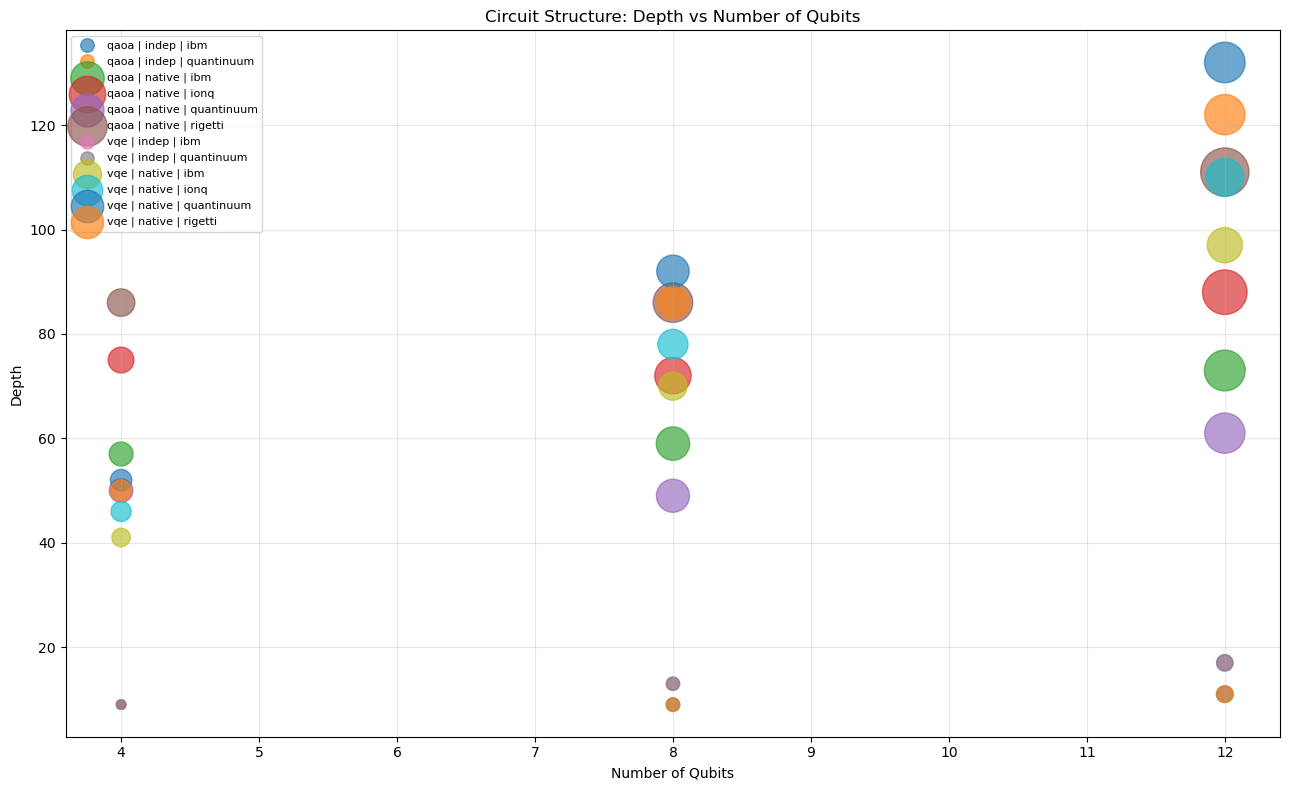

Saved: plots\stacked_two_qubit_gates_by_group_20260317_004135.png


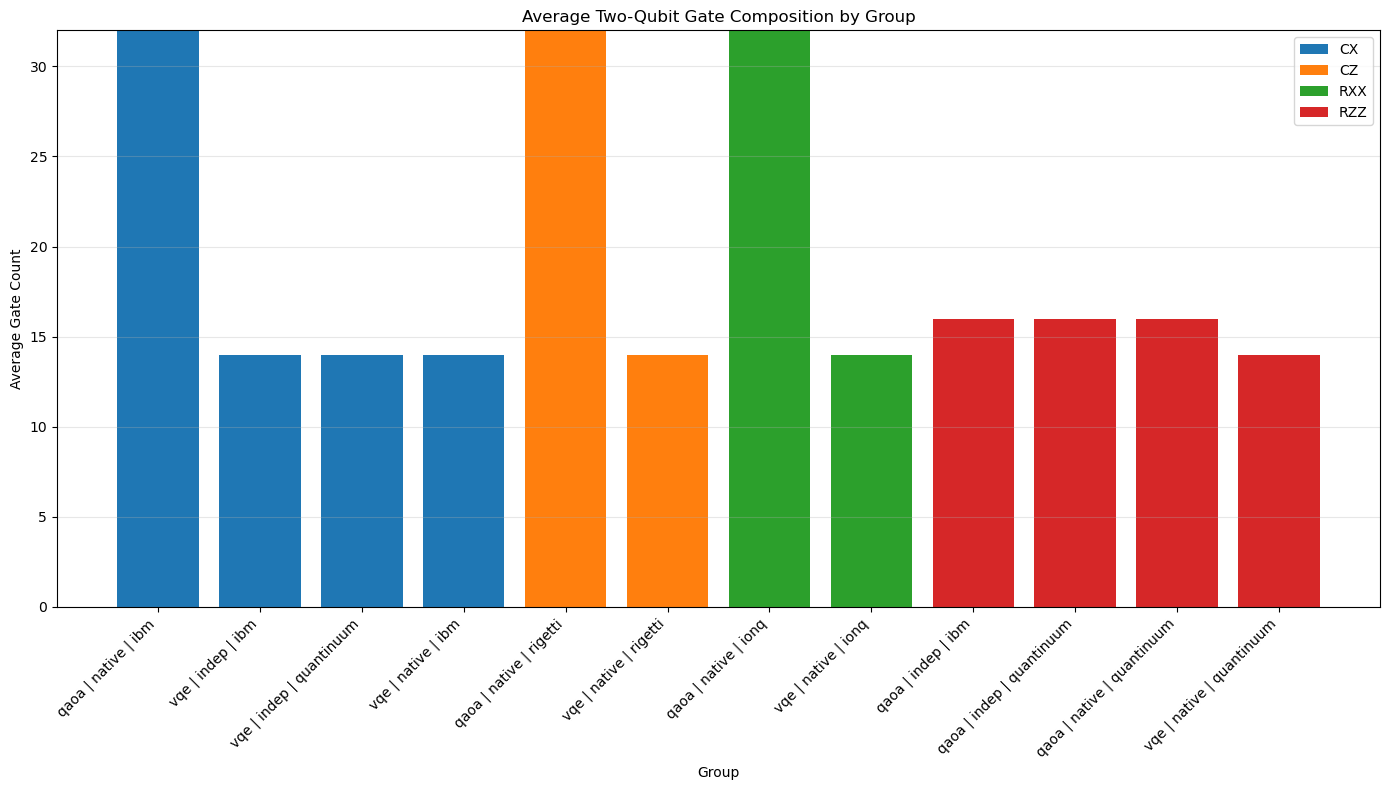

C:\Users\wcamb\AppData\Local\Temp\ipykernel_38164\2817711133.py:201: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=summary_order, patch_artist=False)


Saved: plots\boxplot_depth_by_group_20260317_004135.png


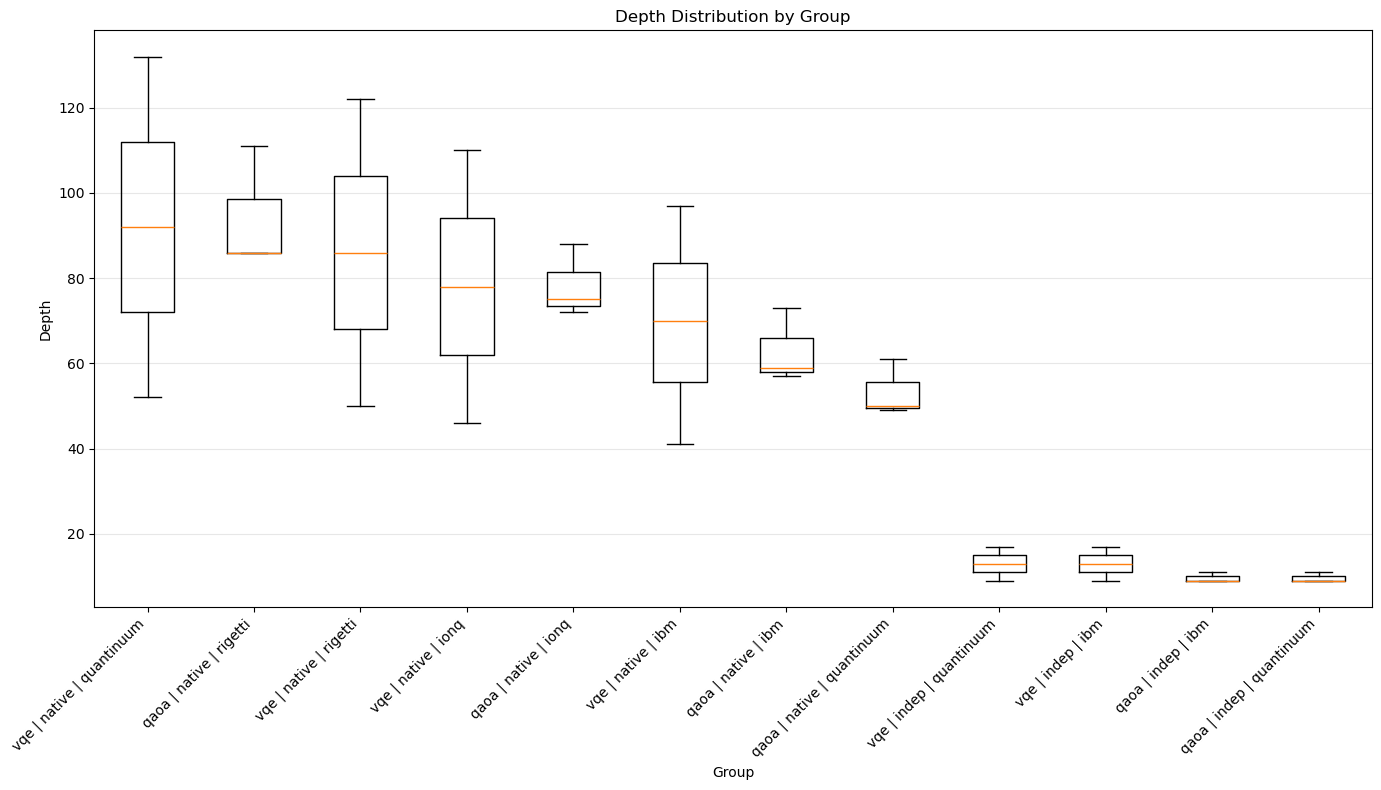

Saved: plots\heatmap_group_metrics_20260317_004135.png


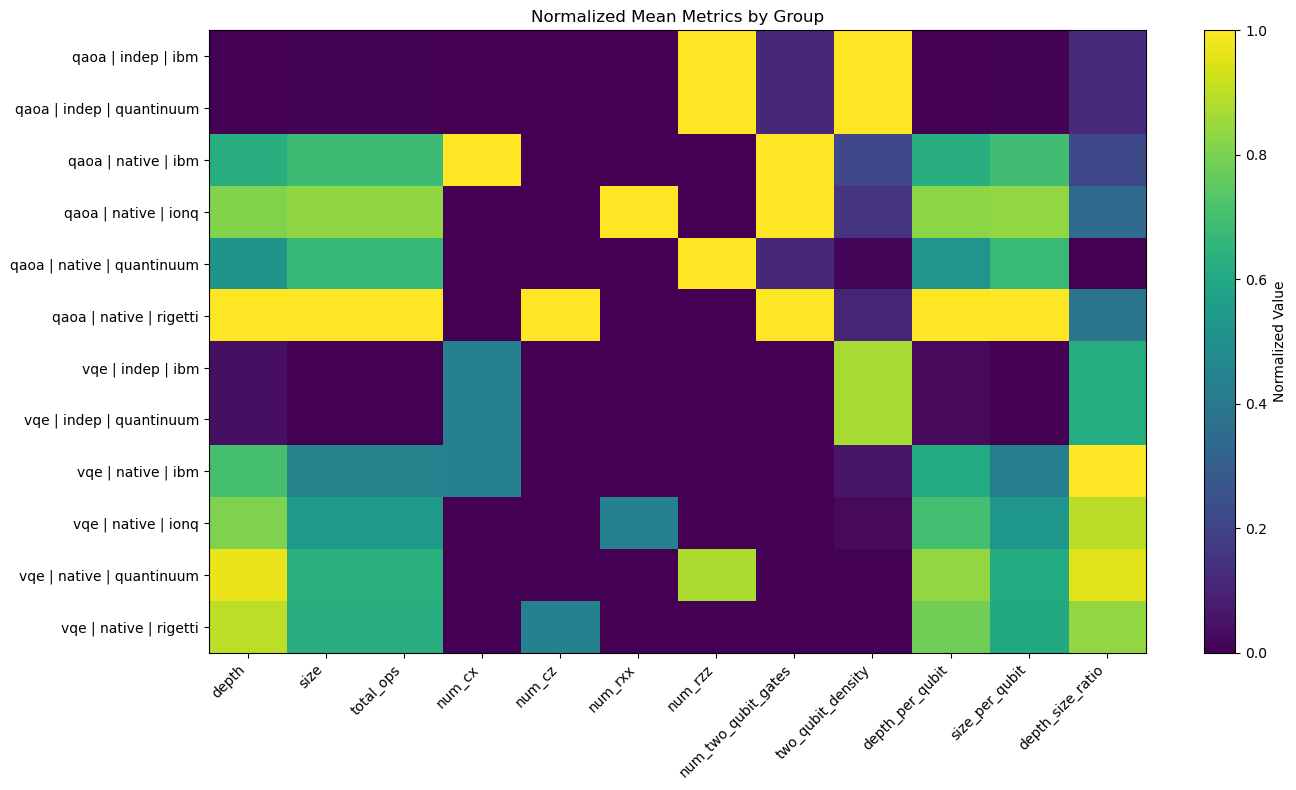

Saved: plots\two_qubit_density_by_group_20260317_004135.png


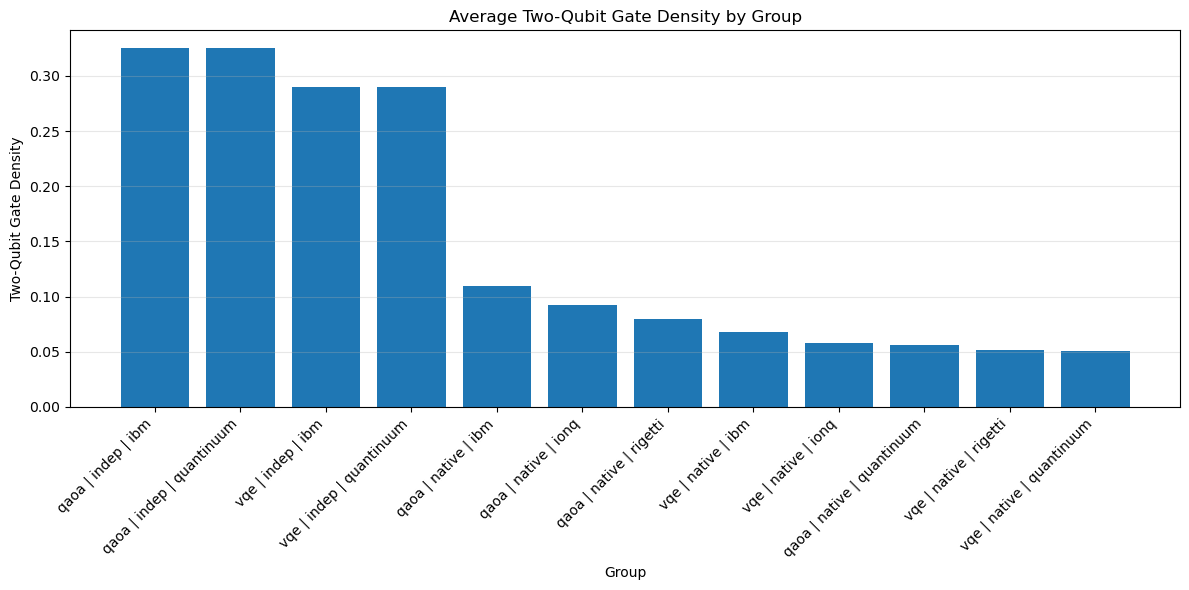

C:\Users\wcamb\AppData\Local\Temp\ipykernel_38164\79559397.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)


Saved: plots\two_qubit_density_boxplot_20260317_004135.png


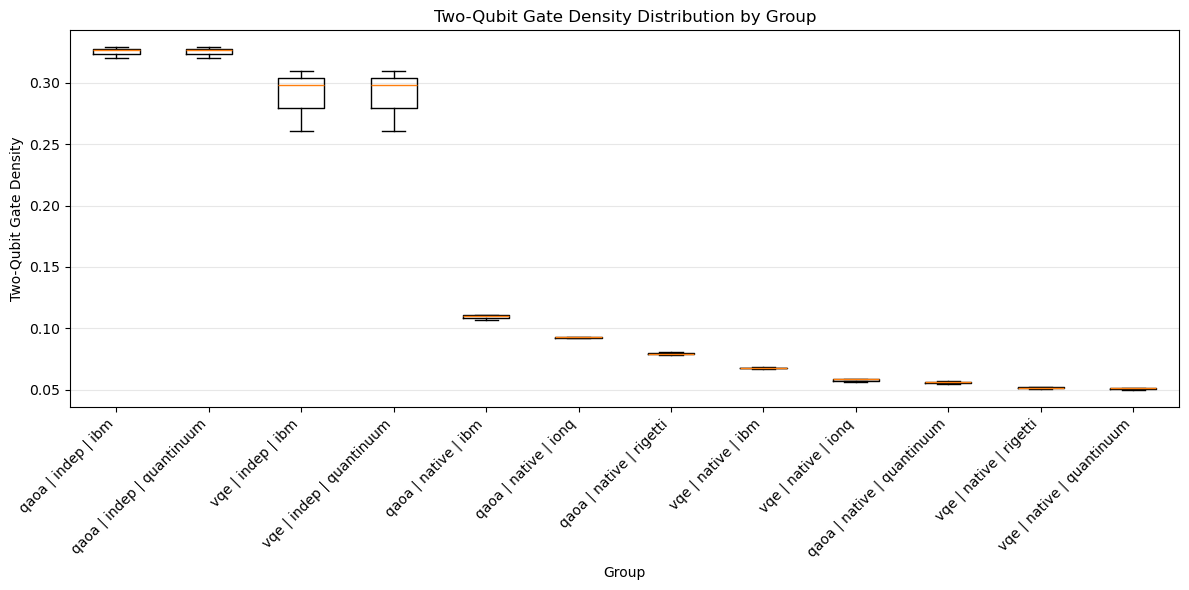

In [45]:
if __name__ == "__main__":
    main()